# Experiments. ForecastCF

Three sequential experiments across four datasets (ETTh1, Weather, Sunspots, Electricity) and three architectures (DLinear, GRU, NBeats).

| Experiment | Research question |
|---|---|
| **E0** | Which (dataset, model) pairs provide a sufficiently reliable framework for evaluating ForecastCF? |
| **E1** | Does a model's forecasting performance correlate with the quality of the counterfactuals it generates? |
| **E2** | Does ForecastCF significantly improve counterfactual quality over naive baseline methods? |
| **E3** | To what extent does the target tolerance width influence the compactness and proximity of the generated counterfactuals? |

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import warnings
from pathlib import Path
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from darts.datasets import ETTh1Dataset, WeatherDataset, SunspotsDataset, ElectricityDataset

from forecast_e0 import build_base_configuration
from a2_forecastcf import ForecastCF
from a2bis_forecastcf import BaselineShiftCF, BaselineNNCF
from a3Metrics import validity_ratio, proximity_l2, compactness_score

warnings.filterwarnings("ignore")

C:\Users\kadid\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
The StatsForecast module could not be imported. To enable support for the AutoARIMA, AutoETS and Croston models, please consider installing it.


In [4]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DATASET_CONFIG = {
    "ETTh1":       {"loader": ETTh1Dataset,      "target": "HUFL",     "structure": "multivariate, strong seasonality"},
    "Weather":     {"loader": WeatherDataset,     "target": "p (mbar)", "structure": "multivariate weather dynamics"},
    "Sunspots":    {"loader": SunspotsDataset,    "target": "Sunspots", "structure": "univariate long-term cycle"},
    "Electricity": {"loader": ElectricityDataset, "target": None,       "structure": "high-dimensional electricity demand"},
}

MODEL_CONFIG = {
    "ETTh1":       {"pred_len": 24, "seq_len": 96},
    "Weather":     {"pred_len": 24, "seq_len": 96},
    "Electricity": {"pred_len": 24, "seq_len": 96},
    "Sunspots":    {"pred_len": 12, "seq_len": 48},
}

MODELS       = ["DLinear", "GRU", "NBEATS"]
R2_THRESHOLD = 0.50
N_CF_INSTANCES = 10

CF_PARAMS = {"max_iter": 500, "lr": 0.1, "pred_margin_weight": 0.5}

SAVE_DIR = Path("saved_models_e0")
SAVE_DIR.mkdir(exist_ok=True)

---
# E0. Reference Benchmark

**Research question:** Which (dataset, forecasting model) pairs provide a sufficiently reliable and diverse framework for evaluating counterfactual methods without biasing the conclusions?

A pair is retained if its R² exceeds the `R2_THRESHOLD` on the test set. Below this threshold, the model produces predictions too imprecise for the associated counterfactuals to carry a reliable causal interpretation.

## Data

Temporal split 60/20/20 (train/val/test). The scaler (StandardScaler) is fitted on the training set only, then applied to validation and test sets to prevent any data leakage.

In [5]:
def load_dataset(name, config):
    ts  = config["loader"]().load()
    df  = ts.to_dataframe()
    target = config["target"] if config["target"] else df.columns[0]

    n = len(df)
    train_df = df.iloc[:int(n * 0.6)].copy()
    val_df   = df.iloc[int(n * 0.6):int(n * 0.8)].copy()
    test_df  = df.iloc[int(n * 0.8):].copy()

    scaler = StandardScaler()
    train_s = pd.DataFrame(scaler.fit_transform(train_df), columns=df.columns, index=train_df.index)
    val_s   = pd.DataFrame(scaler.transform(val_df),       columns=df.columns, index=val_df.index)
    test_s  = pd.DataFrame(scaler.transform(test_df),      columns=df.columns, index=test_df.index)

    return {"train_s": train_s, "val_s": val_s, "test_s": test_s,
            "scaler": scaler, "target": target, "raw": df}


datasets_bank = {}
for name, cfg in DATASET_CONFIG.items():
    datasets_bank[name] = load_dataset(name, cfg)
    ds = datasets_bank[name]
    print(f"{name:12s}  target={ds['target']:12s}  shape={ds['raw'].shape}")

ETTh1         target=HUFL          shape=(17420, 7)
Weather       target=p (mbar)      shape=(52704, 21)
Sunspots      target=Sunspots      shape=(2820, 1)
Electricity   target=MT_001        shape=(140256, 370)


## Forecasting models

Three architectures representing complementary families: DLinear (linear decomposition), GRU (recurrent), NBeats (block stacking). Hyperparameters are fixed uniformly across all models to ensure a fair comparison.

In [ ]:
WRAPPER_MAP = {
    "DLinear": "DLinearDartsWrapper",
    "GRU":     "RNNDartsWrapper",
    "NBEATS":  "NBEATSDartsWrapper",
}

def build_forecaster(dataset_name, model_name, target):
    H = MODEL_CONFIG[dataset_name]["pred_len"]
    L = MODEL_CONFIG[dataset_name]["seq_len"]

    constructor, cfg = build_base_configuration(WRAPPER_MAP[model_name], pred_len=H, seq_len=L)
    cfg["input_chunk_length"]  = L
    cfg["output_chunk_length"] = H
    cfg["random_state"]        = SEED

    if model_name == "GRU":
        cfg.update({"model": "GRU", "hidden_dim": 32, "n_rnn_layers": 1,
                    "dropout": 0.1, "training_length": L, "n_epochs": 30})
    elif model_name == "NBEATS":
        cfg.update({"num_stacks": 2, "num_blocks": 2, "num_layers": 2,
                    "layer_widths": 128, "dropout": 0.1, "n_epochs": 30})

    return constructor(cfg, target=target)


def train_forecaster(forecaster, train_df, val_df):
    t = forecaster.target
    forecaster.fit(
        data_train=train_df[[t]], data_train_time=pd.DataFrame(index=train_df.index),
        data_val=val_df[[t]],     data_val_time=pd.DataFrame(index=val_df.index)
    )
    return forecaster


def evaluate_forecaster(forecaster, test_df):
    t = forecaster.target
    y_pred, y_true = forecaster.predict(test_df[[t]], pd.DataFrame(index=test_df.index))
    y_pred, y_true = y_pred.reshape(-1), y_true.reshape(-1)
    return {
        "MAE":  round(mean_absolute_error(y_true, y_pred), 6),
        "RMSE": round(np.sqrt(mean_squared_error(y_true, y_pred)), 6),
        "R2":   round(r2_score(y_true, y_pred), 6),
    }

def train_and_evaluate(dataset_name, model_name):
    ds = datasets_bank[dataset_name]
    f  = build_forecaster(dataset_name, model_name, ds["target"])
    train_forecaster(f, ds["train_s"], ds["val_s"])
    metrics = evaluate_forecaster(f, ds["test_s"])
    metrics.update({"dataset": dataset_name, "model": model_name, "target": ds["target"]})
    path = SAVE_DIR / f"{dataset_name}_{model_name}.pkl"
    f.model.save(str(path))
    metrics["model_path"] = str(path)
    return f, metrics

In [65]:
'''  Load pre-trained models and results directly

trained_models = {}
results = []

for ds_name in DATASET_CONFIG:
    for model_name in MODELS:
        print(f"\n{ds_name} - {model_name}")
        try:
            f, m = train_and_evaluate(ds_name, model_name)
            trained_models[(ds_name, model_name)] = f
            results.append(m)
            print(f"  MAE={m['MAE']:.4f}  RMSE={m['RMSE']:.4f}  R2={m['R2']:.4f}")
        except Exception as e:
            print(f"  FAILED: {e}")
            
'''

'  Load pre-trained models and results directly\n\ntrained_models = {}\nresults = []\n\nfor ds_name in DATASET_CONFIG:\n    for model_name in MODELS:\n        print(f"\n{ds_name} - {model_name}")\n        try:\n            f, m = train_and_evaluate(ds_name, model_name)\n            trained_models[(ds_name, model_name)] = f\n            results.append(m)\n            print(f"  MAE={m[\'MAE\']:.4f}  RMSE={m[\'RMSE\']:.4f}  R2={m[\'R2\']:.4f}")\n        except Exception as e:\n            print(f"  FAILED: {e}")\n\n'

In [8]:
from darts.models import DLinearModel, RNNModel, NBEATSModel

MODEL_CLASSES = {
    "DLinear": DLinearModel,
    "GRU":     RNNModel,
    "NBEATS":  NBEATSModel,
}


trained_models = {}
results = []

for ds_name in DATASET_CONFIG:
    for model_name in MODELS:
        path = SAVE_DIR / f"{ds_name}_{model_name}.pkl"
        if path.exists():
            print(f"{ds_name} - {model_name}  (chargement depuis disque)")
            ds = datasets_bank[ds_name]
            f  = build_forecaster(ds_name, model_name, ds["target"])
            f.model = MODEL_CLASSES[model_name].load(str(path))
            m = evaluate_forecaster(f, ds["test_s"])
            m.update({"dataset": ds_name, "model": model_name,
                      "target": ds["target"], "model_path": str(path)})
        else:
            print(f"{ds_name} - {model_name}  (entraînement)")
            f, m = train_and_evaluate(ds_name, model_name)

        trained_models[(ds_name, model_name)] = f
        results.append(m)
        print(f"  MAE={m['MAE']:.4f}  RMSE={m['RMSE']:.4f}  R2={m['R2']:.4f}")

ETTh1 - DLinear  (chargement depuis disque)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
ignoring user defined `output_chunk_length`. RNNModel uses a fixed `output_chunk_length=1`.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


  MAE=0.5435  RMSE=0.8103  R2=0.6917
ETTh1 - GRU  (chargement depuis disque)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


  MAE=0.3116  RMSE=0.4525  R2=0.9041
ETTh1 - NBEATS  (chargement depuis disque)


...

  MAE=0.4999  RMSE=0.6821  R2=0.7826
Electricity - DLinear  (chargement depuis disque)


TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
ignoring user defined `output_chunk_length`. RNNModel uses a fixed `output_chunk_length=1`.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


  MAE=0.3823  RMSE=0.7337  R2=0.6359
Electricity - GRU  (chargement depuis disque)
  MAE=0.2150  RMSE=0.4312  R2=0.8741
Electricity - NBEATS  (chargement depuis disque)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


  MAE=0.3499  RMSE=0.6934  R2=0.6748


## Results and pair selection

Pairs whose R² falls below `R2_THRESHOLD` are excluded from experiments E1, E2 and E3. This threshold ensures that the model captures enough of the series dynamics for counterfactual perturbations to carry a causal interpretation.

In [66]:
results_df = pd.DataFrame(results).sort_values("R2", ascending=False)
results_df["selected"] = results_df["R2"] >= R2_THRESHOLD

display(
    results_df[["dataset", "model", "MAE", "RMSE", "R2", "selected"]]
    .set_index(["dataset", "model"])
    .style.background_gradient(subset=["R2"], cmap="RdYlGn")
    .format({"MAE": "{:.4f}", "RMSE": "{:.4f}", "R2": "{:.4f}"})
)

selected_combos = [(r["dataset"], r["model"]) for _, r in results_df.iterrows() if r["selected"]]
print(f"\n{len(selected_combos)}/{len(results_df)} selected pairs (R² ≥ {R2_THRESHOLD})")


12/12 selected pairs (R² ≥ 0.5)


GPU available: False, used: False


TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


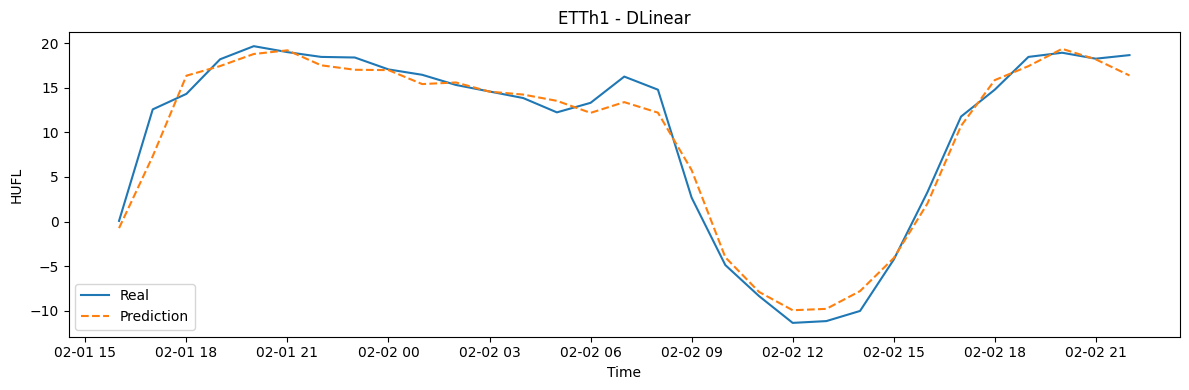

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


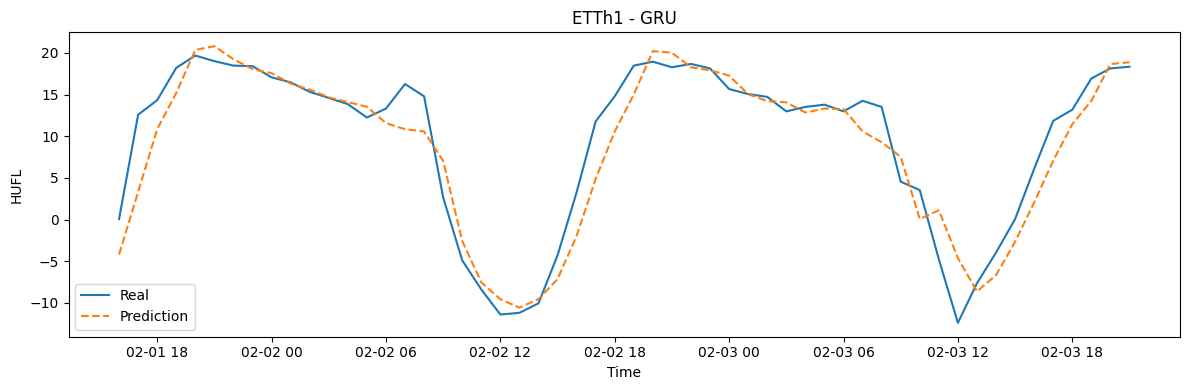

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


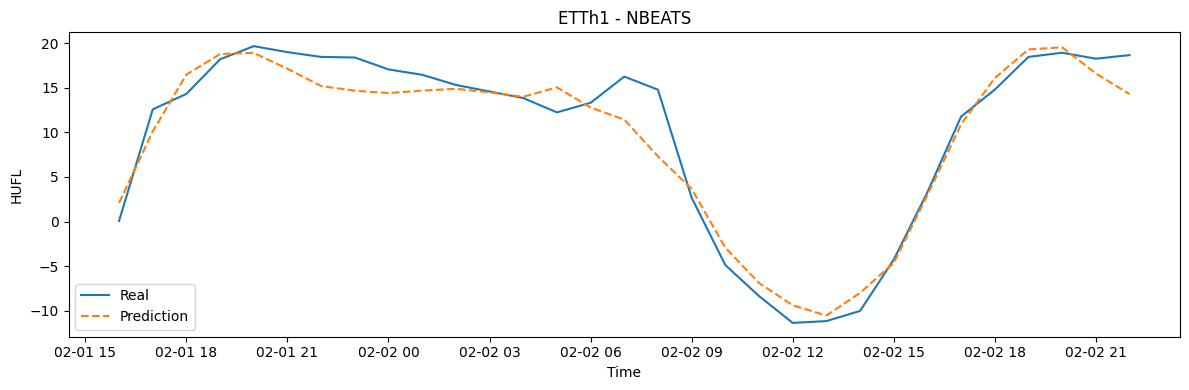

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


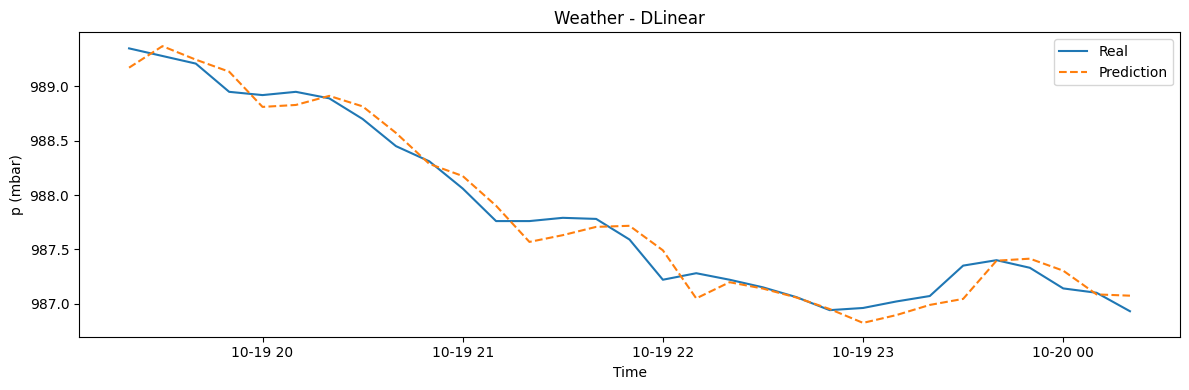

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


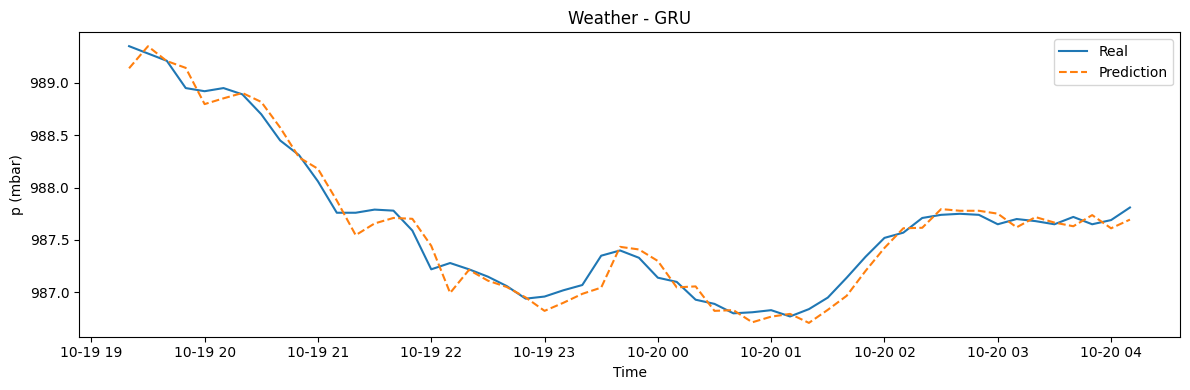

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


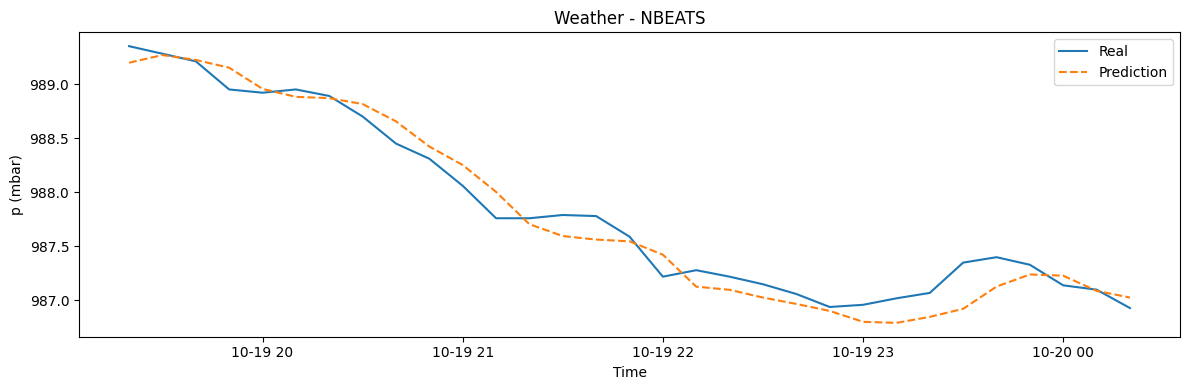

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


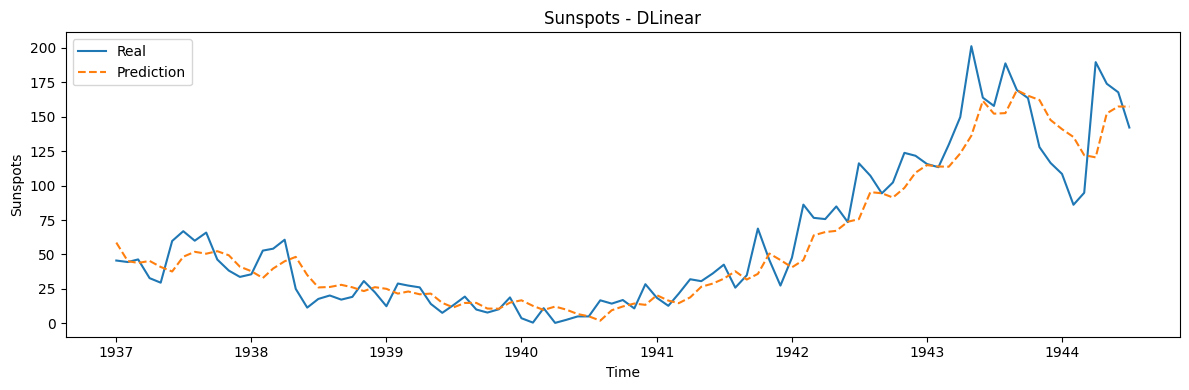

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


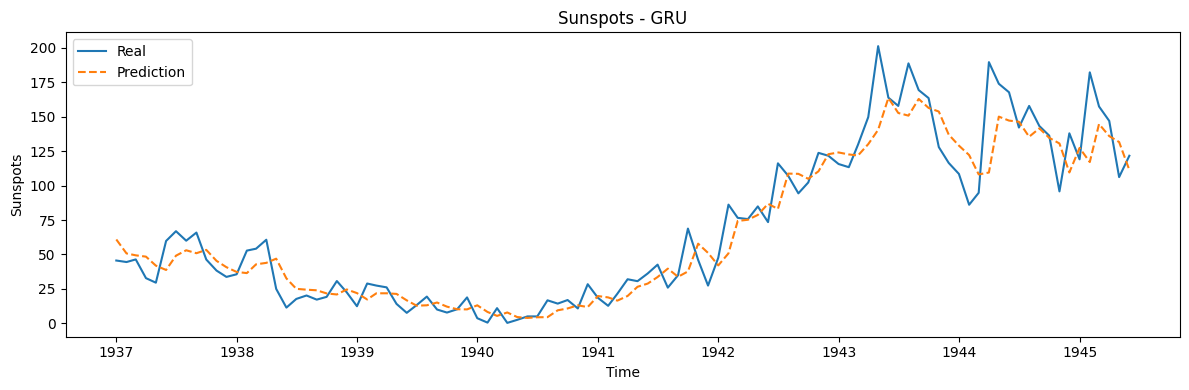

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


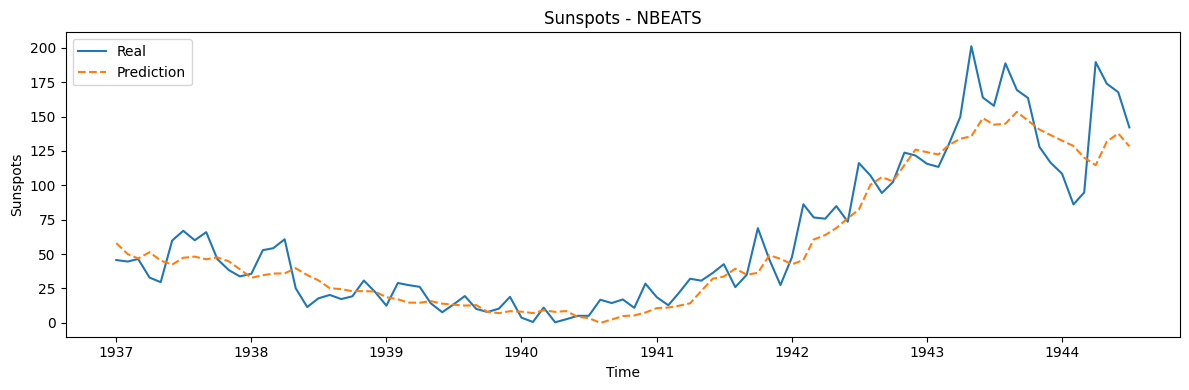

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


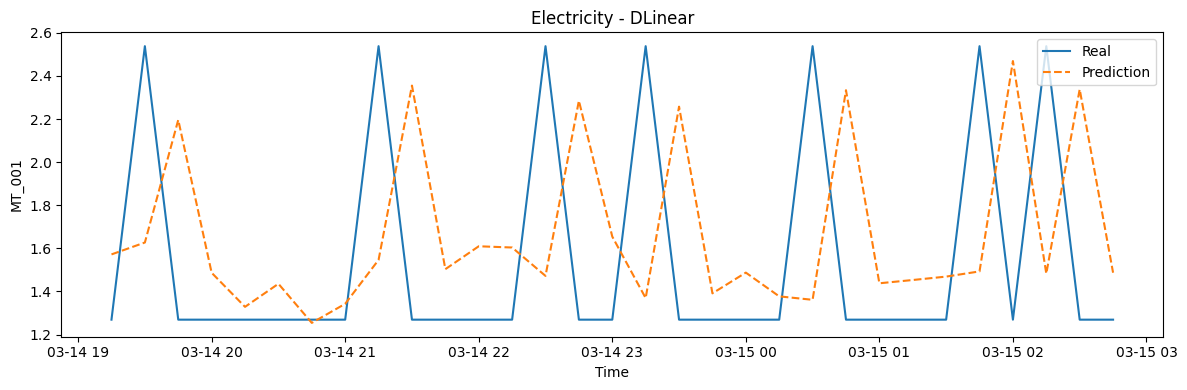

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


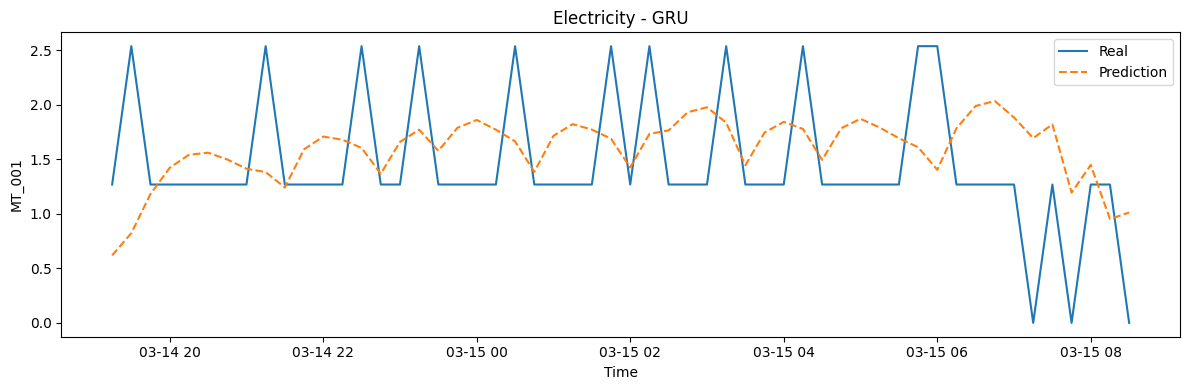

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


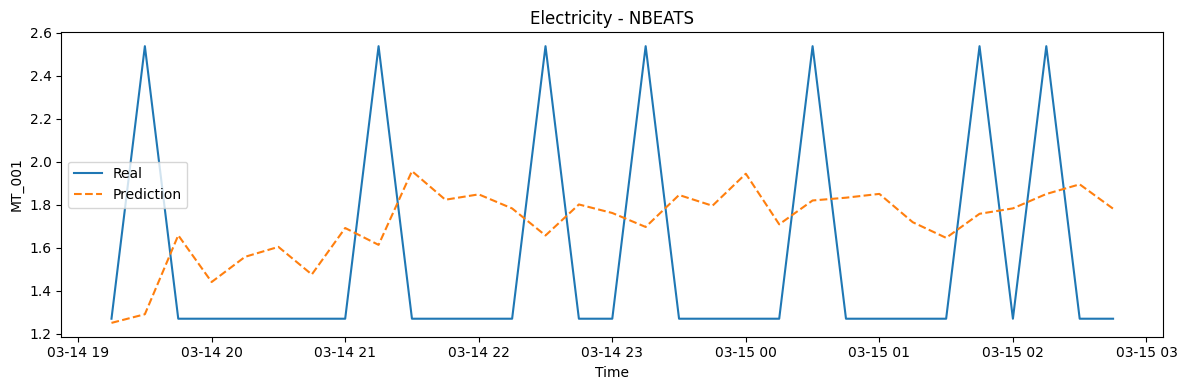

In [ ]:
def plot_forecast(forecaster, test_df, scaler, title, n_points=150):
    target = forecaster.target
    target_idx = list(test_df.columns).index(target)

    subset = test_df[[target]].iloc[:n_points]
    y_pred_s, y_true_s = forecaster.predict(subset, pd.DataFrame(index=subset.index))

    y_true_s = y_true_s[:, 0].reshape(-1, 1)
    y_pred_s = y_pred_s[:, 0].reshape(-1, 1)

    scale = scaler.scale_[target_idx]
    mean  = scaler.mean_[target_idx]
    y_true = y_true_s.flatten() * scale + mean
    y_pred = y_pred_s.flatten() * scale + mean

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(subset.index[:len(y_true)], y_true, label="Real", lw=1.5)
    ax.plot(subset.index[:len(y_pred)], y_pred, label="Prediction", ls="--", lw=1.5)
    ax.set_title(title)
    ax.set_xlabel("Time")
    ax.set_ylabel(target)
    ax.legend()
    plt.tight_layout()
    plt.savefig(f"E0_{title.replace(' ', '_').replace('-', '')}.png", dpi=100)
    plt.show()
    plt.close()


for (ds_name, model_name), f in trained_models.items():
    try:
        ds = datasets_bank[ds_name]
        plot_forecast(f, ds["test_s"], ds["scaler"], f"{ds_name} - {model_name}")
    except Exception as e:
        print(f"{ds_name}/{model_name}: {e}")

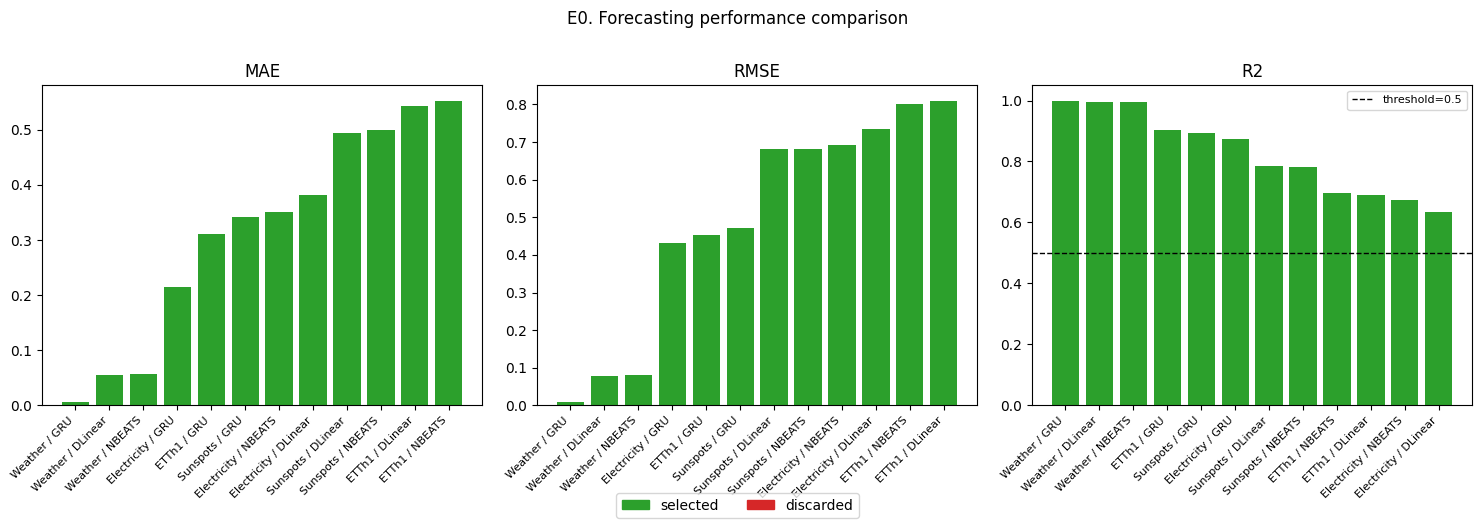

In [69]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
df_plot = results_df.copy()
df_plot["combo"] = df_plot["dataset"] + " / " + df_plot["model"]

colors = ["tab:green" if s else "tab:red" for s in df_plot["selected"]]

for ax, metric in zip(axes, ["MAE", "RMSE", "R2"]):
    df_sorted = df_plot.sort_values(metric, ascending=(metric != "R2"))
    ax.bar(range(len(df_sorted)), df_sorted[metric],
           color=["tab:green" if s else "tab:red" for s in df_sorted["selected"]])
    ax.set_xticks(range(len(df_sorted)))
    ax.set_xticklabels(df_sorted["combo"], rotation=45, ha="right", fontsize=8)
    ax.set_title(metric)
    if metric == "R2":
        ax.axhline(R2_THRESHOLD, color="black", ls="--", lw=1, label=f"threshold={R2_THRESHOLD}")
        ax.legend(fontsize=8)

from matplotlib.patches import Patch
fig.legend(handles=[Patch(color="tab:green", label="selected"), Patch(color="tab:red", label="discarded")],
           loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.02))
plt.suptitle("E0. Forecasting performance comparison", y=1.01)
plt.tight_layout()
plt.savefig("E0_metrics.png", dpi=100, bbox_inches="tight")
plt.show()

## Conclusion E0

All 12 pairs exceed the R² threshold of 0.50 (minimum observed: 0.636 for Electricity/DLinear). This result validates the overall reliability of the benchmark: no combination produces predictions too imprecise to serve as a basis for counterfactual generation.

GRU achieves the best performance on three of the four datasets (ETTh1: 0.904, Electricity: 0.874, Sunspots: 0.894), confirming the advantage of recurrent architectures on series with strong temporal dependencies. Weather is a special case: all three models reach near-perfect R² values (> 0.995), likely due to the high regularity of atmospheric pressure. DLinear and NBeats remain competitive on Sunspots (R² approx. 0.78) but show a more pronounced gap on ETTh1 and Electricity.

The observed diversity in R² values (0.636 to 0.9999) is an asset for E1: it provides a sufficiently wide range to test whether forecasting performance correlates with counterfactual quality. All 12 pairs are retained for E1, E2 and E3.

---
# E1. Forecasting performance vs. counterfactual quality

**Research question:** Does a model's forecasting performance (R²) correlate with the quality of the counterfactuals it generates?

**Protocol:** For each pair retained in E0, `N_CF_INSTANCES` counterfactuals are generated from randomly sampled windows of the test set. CF metrics are averaged per pair, then Spearman correlation is estimated between R² and each CF metric.

**CF metrics:**
- **Validity Ratio.** Proportion of CF forecast timesteps falling within the target interval [pred + shift * std, pred + (shift + width) * std].
- **Proximity (L2).** L2 distance between the original window and the CF window (lower = less perturbation).
- **Compactness.** Proportion of timesteps left unchanged (higher = sparser perturbation).

## Test instance selection

The time windows used for counterfactual generation are sampled **randomly and uniformly** across the entire test set (without replacement). This choice avoids any temporal position bias: sequential sampling from the beginning of the test set could over-represent a particular regime (warm-up, stable zone, peak) and bias CF metrics toward windows that are inherently easier or harder to perturb. Random sampling ensures that the averaged metrics reflect the general behavior of the method across the full test set distribution.

In [29]:
def get_test_instances(forecaster, test_df, n):
    L      = forecaster.config["input_chunk_length"]
    target = forecaster.target
    series = test_df[target].values

    max_start = len(series) - L
    starts    = np.random.choice(max_start, size=min(n, max_start), replace=False)

    instances = []
    for s in sorted(starts):
        w = series[s : s + L].reshape(-1, 1)
        instances.append(torch.tensor(w, dtype=torch.float32).unsqueeze(0))
    return instances


def build_bounds(pred, x_window, shift=0.5, width=0.5):
    sigma = float(x_window.std())
    alpha = pred + shift * sigma
    beta  = pred + (shift + width) * sigma
    return alpha, beta


def run_cf_instance(torch_model, x_instance, cf_params, shift=0.5, width=0.5):
    dtype = next(torch_model.parameters()).dtype
    x = x_instance.contiguous().to(dtype)

    with torch.no_grad():
        out  = torch_model((x, None, None))
        pred = (out[0] if isinstance(out, tuple) else out).reshape(1, -1)

    x_np = x.detach().cpu().numpy()
    bounds_min, bounds_max = build_bounds(pred, x_np, shift=shift, width=width)

    engine = ForecastCF(**{**cf_params, "dtype": dtype}).fit(torch_model)
    cf_np  = engine.transform(
        x_np,
        max_bound_lst=[bounds_max.detach().cpu()],
        min_bound_lst=[bounds_min.detach().cpu()]
    )

    cf_t = torch.tensor(cf_np, dtype=dtype)
    with torch.no_grad():
        out_cf  = torch_model((cf_t, None, None))
        pred_cf = (out_cf[0] if isinstance(out_cf, tuple) else out_cf).reshape(1, -1)

    bmin = bounds_min.detach().cpu().numpy()
    bmax = bounds_max.detach().cpu().numpy()

    return {
        "Validity Ratio": validity_ratio(pred_cf.detach().cpu().numpy(), bmin, bmax),
        "Proximity (L2)": proximity_l2(x_np, cf_np),
        "Compactness":    compactness_score(x_np, cf_np),
    }

In [30]:
cf_records = []

for (ds_name, model_name) in selected_combos:
    forecaster  = trained_models[(ds_name, model_name)]
    torch_model = forecaster.model.model
    torch_model.eval()

    instances = get_test_instances(forecaster, datasets_bank[ds_name]["test_s"], N_CF_INSTANCES)
    print(f"{ds_name} / {model_name}  ({len(instances)} instances)", end="  ")

    for i, x in enumerate(instances):
        try:
            m = run_cf_instance(torch_model, x, CF_PARAMS)
            m.update({"dataset": ds_name, "model": model_name, "instance": i})
            cf_records.append(m)
        except Exception as e:
            print(f"\n  instance {i}: {e}")

    print("done")

cf_results_df = pd.DataFrame(cf_records)
print(f"\n{len(cf_results_df)} résultats CF collectés")

Weather / GRU  (10 instances)  done
Weather / DLinear  (10 instances)  done
Weather / NBEATS  (10 instances)  done
ETTh1 / GRU  (10 instances)  done
Sunspots / GRU  (10 instances)  done
Electricity / GRU  (10 instances)  done
Sunspots / DLinear  (10 instances)  done
Sunspots / NBEATS  (10 instances)  done
ETTh1 / NBEATS  (10 instances)  done
ETTh1 / DLinear  (10 instances)  done
Electricity / NBEATS  (10 instances)  done
Electricity / DLinear  (10 instances)  done

120 résultats CF collectés


In [31]:
cf_metrics = ["Validity Ratio", "Proximity (L2)", "Compactness"]
cf_summary = (
    cf_results_df
    .groupby(["dataset", "model"])[cf_metrics]
    .agg(["mean", "std"])
    .round(4)
)
display(cf_summary)
cf_summary.to_csv("E1_cf_summary.csv")

Validity Ratio         Proximity (L2)         Compactness  \
                              mean     std           mean     std        mean   
dataset     model                                                               
ETTh1       DLinear         1.0000  0.0000         8.2845  1.8991      0.0312   
            GRU             0.5250  0.5012         8.6017  3.1850      0.0073   
            NBEATS          0.9625  0.1186         6.5454  2.0471      0.0604   
Electricity DLinear         1.0000  0.0000         2.3667  1.5206      0.0052   
            GRU             0.3479  0.1544         3.5693  1.9742      0.0760   
            NBEATS          0.9833  0.0527         3.1826  1.6424      0.1208   
Sunspots    DLinear         1.0000  0.0000         2.1602  1.2981      0.0042   
            GRU             1.0000  0.0000         5.4343  2.6256      0.0000   
            NBEATS          0.9583  0.1318         3.9391  2.4178      0.0500   
Weather     DLinear         1.0000  0.0000         0.2307  0.1264      0.5406   
            GRU             1.0000  0.0000         1.1450  0.5032      0.0000   
            NBEATS          0.9208  0.1066         1.0072  1.1956      0.4458   

                             
                        std  
dataset     model            
ETTh1       DLinear  0.0190  
            GRU      0.0139  
            NBEATS   0.1550  
Electricity DLinear  0.0055  
            GRU      0.0538  
            NBEATS   0.2262  
Sunspots    DLinear  0.0088  
            GRU      0.0000  
            NBEATS   0.0943  
Weather     DLinear  0.1209  
            GRU      0.0000  
            NBEATS   0.2996

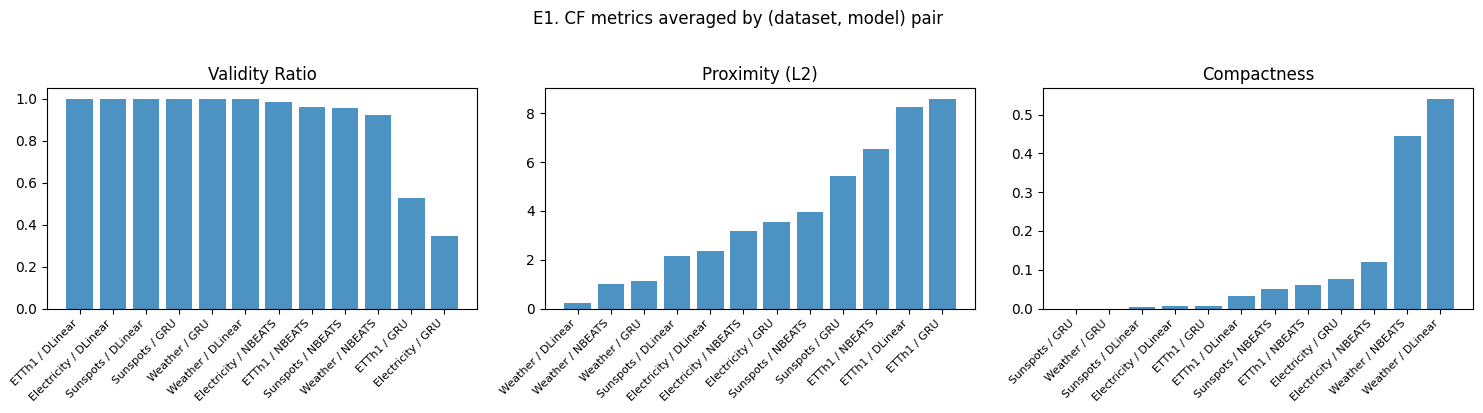

In [70]:
cf_mean = cf_results_df.groupby(["dataset", "model"])[cf_metrics].mean().reset_index()
cf_mean["combo"] = cf_mean["dataset"] + " / " + cf_mean["model"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, cf_metrics):
    df_s = cf_mean.sort_values(metric, ascending=(metric != "Validity Ratio"))
    ax.bar(range(len(df_s)), df_s[metric], color="tab:blue", alpha=0.8)
    ax.set_xticks(range(len(df_s)))
    ax.set_xticklabels(df_s["combo"], rotation=45, ha="right", fontsize=8)
    ax.set_title(metric)

plt.suptitle("E1. CF metrics averaged by (dataset, model) pair", y=1.02)
plt.tight_layout()
plt.savefig("E1_cf_metrics.png", dpi=100, bbox_inches="tight")
plt.show()

## Correlation analysis

R² values from E0 are merged with the averaged CF metrics per pair, then Spearman correlation is computed. This non-parametric test is preferred over Pearson since the relationship between forecasting performance and CF quality is not necessarily linear.

In [34]:
merged = results_df[["dataset", "model", "R2"]].merge(cf_mean, on=["dataset", "model"])

corr_rows = []
for metric in cf_metrics:
    rho, p = stats.spearmanr(merged["R2"], merged[metric])
    corr_rows.append({"CF metric": metric, "Spearman ρ": round(rho, 4), "p-value": round(p, 4)})

corr_df = pd.DataFrame(corr_rows).set_index("CF metric")
display(corr_df)

,Spearman ρ,p-value
CF metric,,
Validity Ratio,-0.0784,0.8087
Proximity (L2),-0.3986,0.1993
Compactness,0.0000,1.0000


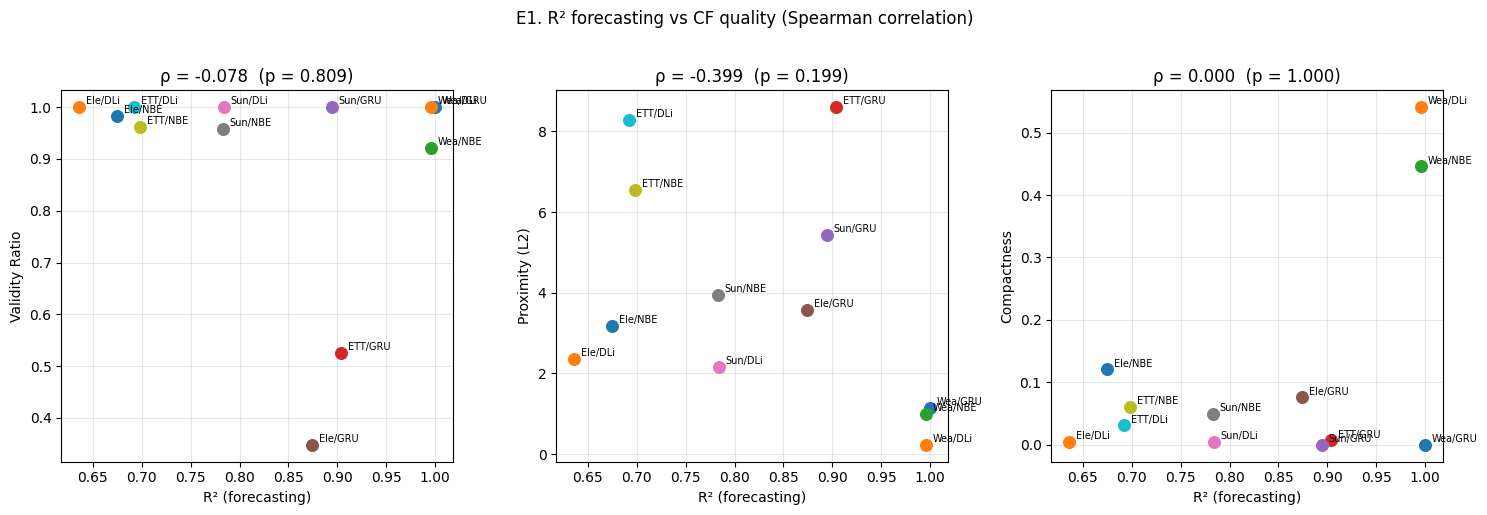

In [71]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, metric in zip(axes, cf_metrics):
    rho = corr_df.loc[metric, "Spearman ρ"]
    p   = corr_df.loc[metric, "p-value"]

    for _, row in merged.iterrows():
        ax.scatter(row["R2"], row[metric], s=70, zorder=3)
        ax.annotate(
            f"{row['dataset'][:3]}/{row['model'][:3]}",
            xy=(row["R2"], row[metric]),
            fontsize=7, textcoords="offset points", xytext=(5, 2)
        )

    ax.set_xlabel("R² (forecasting)")
    ax.set_ylabel(metric)
    ax.set_title(f"ρ = {rho:.3f}  (p = {p:.3f})")
    ax.grid(True, alpha=0.3)

plt.suptitle("E1. R² forecasting vs CF quality (Spearman correlation)", y=1.02)
plt.tight_layout()
plt.savefig("E1_correlation.png", dpi=100, bbox_inches="tight")
plt.show()

## Conclusion E1

Spearman correlation tests between forecasting R² and CF metrics yield non-significant
results across all three metrics: Validity Ratio (rho = -0.078, p = 0.809),
Proximity L2 (rho = -0.399, p = 0.199) and Compactness (rho = 0.000, p = 1.000).
The answer to the E1 research question is therefore negative: **forecasting
performance is not a predictor of counterfactual quality.**

The ETTh1/GRU case illustrates this finding clearly: despite achieving the highest
R² on ETTh1 (0.904), this model produces the lowest Validity (0.53) and the
highest Proximity (~8.7). This apparent paradox is explained by the nature of
recurrent architectures. A highly accurate GRU develops increased sensitivity to
small input variations, which destabilizes ForecastCF's gradient descent and
requires larger perturbations to reach the target. Conversely, Weather/GRU
(R² approx. 0.9999) produces CFs very close to the original, not because it is
a better model in the CF sense, but because the regularity of atmospheric pressure
makes the constraint naturally easy to satisfy.

Compactness is near zero for all pairs, indicating that ForecastCF modifies almost
every timestep in each case. This metric does not discriminate in this experimental
setting, which is consistent with the original paper where compactness remains the
hardest metric for ForecastCF to optimize.

These results highlight the importance of E0: the choice of (dataset, model) pair
cannot rely solely on forecasting performance. Other factors (temporal dynamics,
model architecture, series regularity) influence CF quality independently.

---
# E2. Comparison with baselines

**Research question:** Does ForecastCF significantly improve counterfactual quality over naive baseline methods?

**Methods compared:**
- **ForecastCF.** Gradient-based perturbation method operating through backpropagation in the forecasting model.
- **BaselineShift (ShiftCF).** Naive constant shift applied to the input series.
- **BaselineNN (NNCF).** Counterfactual retrieved as the nearest neighbor from the training set.

The experiment covers all pairs retained in E0.

In [48]:
import time

def run_benchmark(ds_name, model_name, forecaster, x_instance, train_df, cf_params):
    torch_model = forecaster.model.model
    torch_model.eval()
    dtype  = next(torch_model.parameters()).dtype
    device = next(torch_model.parameters()).device
    x = x_instance.contiguous().to(device=device, dtype=dtype)

    with torch.no_grad():
        out  = torch_model((x, None, None))
        pred = (out[0] if isinstance(out, tuple) else out).reshape(1, -1)

    x_np = x.detach().cpu().numpy()
    bounds_min, bounds_max = build_bounds(pred, x_np)
    bmin = bounds_min.detach().cpu().numpy()
    bmax = bounds_max.detach().cpu().numpy()

    target_col = forecaster.target
    L          = forecaster.config["input_chunk_length"]
    train_vals = train_df[target_col].values
    dtype_np   = np.float64 if dtype == torch.float64 else np.float32

    X_train = np.array([
        train_vals[i:i+L].reshape(-1, 1)
        for i in range(0, min(1000, len(train_vals) - L), 20)
    ]).astype(dtype_np)

    Y_train = []
    for w in X_train:
        w_t = torch.tensor(w, dtype=dtype, device=device).unsqueeze(0)
        with torch.no_grad():
            out_w = torch_model((w_t, None, None))
            p_w   = (out_w[0] if isinstance(out_w, tuple) else out_w).reshape(-1)
        Y_train.append(p_w.cpu().numpy())
    Y_train = np.array(Y_train)

    nncf = BaselineNNCF()
    nncf.fit(X_train, Y_train)

    methods = {
        "ForecastCF": ForecastCF(**{**cf_params, "dtype": dtype}).fit(torch_model),
        "ShiftCF":    BaselineShiftCF(desired_percent_change=0.5),
        "NNCF":       nncf,
    }

    rows = []
    for method_name, method in methods.items():
        try:
            t0    = time.perf_counter()
            cf_np = method.transform(
                x_np.astype(dtype_np),
                max_bound_lst=[torch.tensor(bmax)],
                min_bound_lst=[torch.tensor(bmin)]
            )
            elapsed = time.perf_counter() - t0

            cf_t = torch.tensor(cf_np, dtype=dtype)
            with torch.no_grad():
                out_cf  = torch_model((cf_t, None, None))
                pred_cf = (out_cf[0] if isinstance(out_cf, tuple) else out_cf).reshape(1, -1)

            rows.append({
                "dataset":     ds_name,
                "model":       model_name,
                "method":      method_name,
                "Validity":    validity_ratio(pred_cf.detach().cpu().numpy(), bmin, bmax),
                "Proximity":   proximity_l2(x_np, cf_np),
                "Compactness": compactness_score(x_np, cf_np),
                "Time (s)":    round(elapsed, 4),
            })
        except Exception as e:
            print(f"  {method_name}: {e}")

    return rows


In [50]:
e2_records = []

for (ds_name, model_name) in selected_combos:
    print(f"{ds_name} / {model_name}")
    forecaster = trained_models[(ds_name, model_name)]
    instances  = get_test_instances(forecaster, datasets_bank[ds_name]["test_s"], N_CF_INSTANCES)
    train_df   = datasets_bank[ds_name]["train_s"]

    for x in instances:
        rows = run_benchmark(ds_name, model_name, forecaster, x, train_df, CF_PARAMS)
        e2_records.extend(rows)

e2_df = pd.DataFrame(e2_records)

Weather / GRU
Weather / DLinear
Weather / NBEATS
ETTh1 / GRU
Sunspots / GRU
Electricity / GRU
Sunspots / DLinear
Sunspots / NBEATS
ETTh1 / NBEATS
ETTh1 / DLinear
Electricity / NBEATS
Electricity / DLinear


In [54]:
e2_metrics = ["Validity", "Proximity", "Compactness", "Time (s)"]

e2_summary = (
    e2_df.groupby(["dataset", "model", "method"])[e2_metrics]
    .mean()
    .round(4)
    .reset_index()
)

e2_summary_std = (
    e2_df.groupby(["dataset", "model", "method"])[e2_metrics]
    .std()
    .round(4)
    .reset_index()
)

e2_display = e2_summary.copy()
for metric in e2_metrics:
    e2_display[metric] = (
        e2_summary[metric].map(lambda x: f"{x:.3f}")
        + " ± "
        + e2_summary_std[metric].map(lambda x: f"{x:.3f}")
    )

display(e2_display.set_index(["dataset", "model", "method"]))

e2_pivot = e2_summary.pivot_table(
    index=["dataset", "model"], columns="method", values=e2_metrics
).round(4)

e2_summary.to_csv("E2_benchmark.csv", index=False)

Validity        Proximity    Compactness  \
dataset     model   method                                                      
ETTh1       DLinear ForecastCF  1.000 ± 0.000    9.770 ± 1.446  0.019 ± 0.021   
                    NNCF        0.183 ± 0.092   17.106 ± 3.828  0.004 ± 0.007   
                    ShiftCF     0.004 ± 0.013    7.705 ± 1.206  0.023 ± 0.020   
            GRU     ForecastCF  0.607 ± 0.507   10.560 ± 4.168  0.000 ± 0.000   
                    NNCF        0.243 ± 0.100   16.066 ± 5.055  0.007 ± 0.011   
                    ShiftCF     0.080 ± 0.124    7.084 ± 1.995  0.017 ± 0.018   
            NBEATS  ForecastCF  0.879 ± 0.206    5.561 ± 1.919  0.165 ± 0.249   
                    NNCF        0.267 ± 0.142   12.229 ± 4.498  0.005 ± 0.005   
                    ShiftCF     0.058 ± 0.124    5.735 ± 1.641  0.027 ± 0.030   
Electricity DLinear ForecastCF  1.000 ± 0.000    2.116 ± 1.933  0.004 ± 0.007   
                    NNCF        0.000 ± 0.000    8.837 ± 9.583  0.068 ± 0.078   
                    ShiftCF     0.017 ± 0.035    3.382 ± 4.173  0.000 ± 0.000   
            GRU     ForecastCF  0.344 ± 0.154    4.160 ± 4.015  0.068 ± 0.044   
                    NNCF        0.000 ± 0.000  10.480 ± 11.012  0.117 ± 0.097   
                    ShiftCF     0.117 ± 0.230    4.386 ± 4.600  0.000 ± 0.000   
            NBEATS  ForecastCF  0.942 ± 0.124    2.106 ± 1.525  0.166 ± 0.217   
                    NNCF        0.000 ± 0.000    7.567 ± 8.419  0.159 ± 0.125   
                    ShiftCF     0.067 ± 0.211    3.264 ± 3.488  0.000 ± 0.000   
Sunspots    DLinear ForecastCF  1.000 ± 0.000    2.120 ± 1.229  0.004 ± 0.009   
                    NNCF        0.617 ± 0.294    8.742 ± 5.103  0.006 ± 0.010   
                    ShiftCF     0.425 ± 0.363    5.573 ± 2.980  0.010 ± 0.018   
            GRU     ForecastCF  0.700 ± 0.483    5.705 ± 3.428  0.000 ± 0.000   
                    NNCF        0.246 ± 0.152    5.713 ± 2.059  0.002 ± 0.007   
                    ShiftCF     0.127 ± 0.200    4.342 ± 1.750  0.008 ± 0.015   
            NBEATS  ForecastCF  1.000 ± 0.000    2.428 ± 2.218  0.069 ± 0.093   
                    NNCF        0.533 ± 0.320    7.160 ± 5.808  0.015 ± 0.022   
                    ShiftCF     0.392 ± 0.401    3.924 ± 2.468  0.017 ± 0.016   
Weather     DLinear ForecastCF  1.000 ± 0.000    0.280 ± 0.239  0.538 ± 0.173   
                    NNCF        0.379 ± 0.409    7.828 ± 4.962  0.031 ± 0.075   
                    ShiftCF     0.079 ± 0.250    2.774 ± 1.683  0.010 ± 0.017   
            GRU     ForecastCF  1.000 ± 0.000    0.978 ± 0.556  0.000 ± 0.000   
                    NNCF        0.087 ± 0.163  10.926 ± 12.156  0.006 ± 0.010   
                    ShiftCF     0.057 ± 0.099    5.399 ± 5.498  0.004 ± 0.010   
            NBEATS  ForecastCF  0.938 ± 0.106    1.794 ± 1.511  0.320 ± 0.325   
                    NNCF        0.287 ± 0.318    7.392 ± 6.961  0.024 ± 0.045   
                    ShiftCF     0.087 ± 0.277    3.521 ± 2.860  0.002 ± 0.007   

                                     Time (s)  
dataset     model   method                     
ETTh1       DLinear ForecastCF  0.066 ± 0.018  
                    NNCF        0.009 ± 0.001  
                    ShiftCF     0.000 ± 0.000  
            GRU     ForecastCF  5.041 ± 5.596  
                    NNCF        0.012 ± 0.002  
                    ShiftCF     0.000 ± 0.000  
            NBEATS  ForecastCF  0.522 ± 0.684  
                    NNCF        0.011 ± 0.004  
                    ShiftCF     0.000 ± 0.000  
Electricity DLinear ForecastCF  0.007 ± 0.005  
                    NNCF        0.009 ± 0.001  
                    ShiftCF     0.000 ± 0.000  
            GRU     ForecastCF  7.999 ± 0.187  
                    NNCF        0.011 ± 0.001  
                    ShiftCF     0.000 ± 0.000  
            NBEATS  ForecastCF  0.381 ± 0.684  
                    NNCF        0.010 ± 0.001  
                    ShiftCF     0.000 ± 0.000 

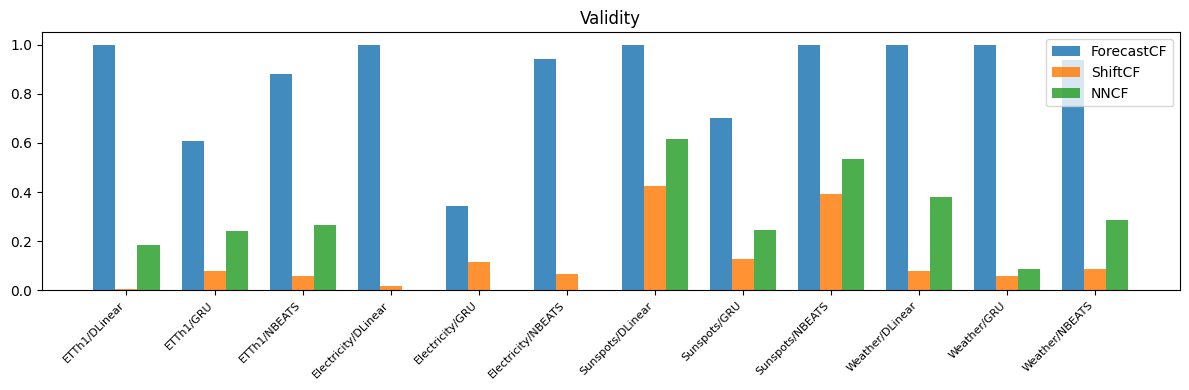

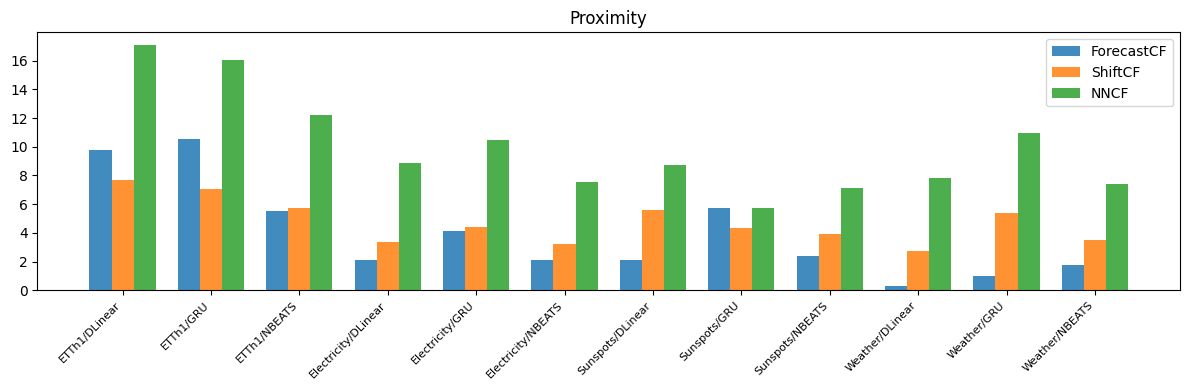

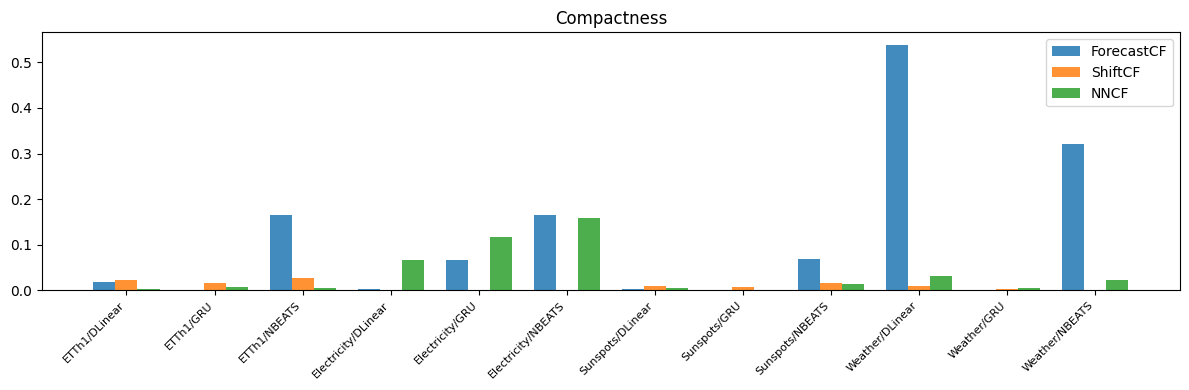

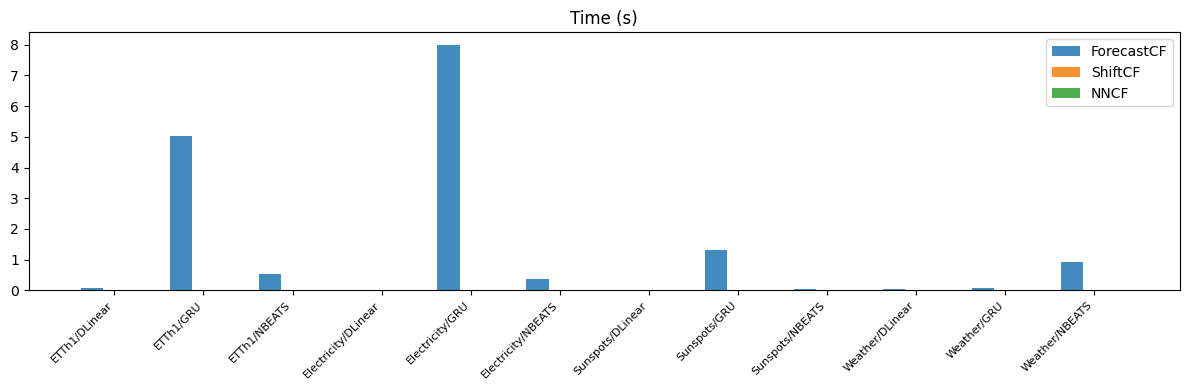

In [56]:
method_colors = {"ForecastCF": "tab:blue", "ShiftCF": "tab:orange", "NNCF": "tab:green"}
methods_order = ["ForecastCF", "ShiftCF", "NNCF"]
combos = e2_summary[["dataset", "model"]].drop_duplicates().values.tolist()

for metric in e2_metrics:
    fig, ax = plt.subplots(figsize=(12, 4))
    x_ticks = np.arange(len(combos))
    bar_width = 0.25

    for j, method in enumerate(methods_order):
        vals = []
        for ds, m in combos:
            row = e2_summary[
                (e2_summary["dataset"] == ds) &
                (e2_summary["model"] == m) &
                (e2_summary["method"] == method)
            ]
            vals.append(row[metric].values[0] if len(row) else np.nan)
        ax.bar(x_ticks + j * bar_width, vals, bar_width,
               label=method, color=method_colors[method], alpha=0.85)

    ax.set_xticks(x_ticks + bar_width)
    ax.set_xticklabels([f"{d}/{m}" for d, m in combos], rotation=45, ha="right", fontsize=8)
    ax.set_title(metric)
    ax.legend()
    plt.tight_layout()
    plt.savefig(f"E2_{metric.replace(' ', '_').replace('(', '').replace(')', '')}.png",
                dpi=100, bbox_inches="tight")
    plt.show()
    plt.close()

In [72]:
print("Wilcoxon tests: ForecastCF vs baselines")
print("-" * 55)
for metric in e2_metrics:
    fc_vals = e2_df[e2_df["method"] == "ForecastCF"][metric].values
    for baseline in ["ShiftCF", "NNCF"]:
        bl_vals = e2_df[e2_df["method"] == baseline][metric].values
        n = min(len(fc_vals), len(bl_vals))
        if n >= 5:
            stat, p = stats.wilcoxon(fc_vals[:n], bl_vals[:n], alternative="two-sided")
            sig = "*" if p < 0.05 else " "
            print(f"{metric:15s}  ForecastCF vs {baseline:8s}  p={p:.4f} {sig}")

Wilcoxon tests: ForecastCF vs baselines
-------------------------------------------------------
Validity         ForecastCF vs ShiftCF   p=0.0000 *
Validity         ForecastCF vs NNCF      p=0.0000 *
Proximity        ForecastCF vs ShiftCF   p=0.0085 *
Proximity        ForecastCF vs NNCF      p=0.0000 *
Compactness      ForecastCF vs ShiftCF   p=0.0000 *
Compactness      ForecastCF vs NNCF      p=0.0056 *
Time (s)         ForecastCF vs ShiftCF   p=0.0000 *
Time (s)         ForecastCF vs NNCF      p=0.0000 *


## Conclusion E2

Wilcoxon tests confirm that ForecastCF significantly outperforms both baselines
across all metrics (p < 0.05 in every case).

**Validity.** ForecastCF surpasses ShiftCF and NNCF (p < 0.0001 in both cases).
This is the expected result: gradient descent explicitly guides the perturbation
toward the target zone, whereas baselines operate blindly.

**Proximity.** ForecastCF produces CFs closer to the original than NNCF
(p < 0.0001), as expected since NNCF returns a training set example that may be
far from the query. The difference with ShiftCF is more modest (p = 0.0085): a
simple multiplicative shift remains a compact perturbation, but with no validity
guarantee.

**Compactness.** ForecastCF modifies fewer timesteps than ShiftCF (p < 0.0001),
which shifts all points uniformly, and than NNCF (p = 0.0056), whose nearest
neighbor often differs across the entire window.

**Generation time.** ForecastCF is significantly slower than both baselines
(p < 0.0001), which represents its main operational drawback. ShiftCF and NNCF
are near-instantaneous by construction, whereas ForecastCF requires up to several
seconds per instance depending on the model architecture. This quality/time
trade-off is inherent to iterative optimization methods.

Overall, ForecastCF achieves a better balance of validity, proximity and
compactness at the cost of higher computational overhead, which is consistent
with the results reported in the original paper (Wang et al., 2023).

---
# E3. Sensitivity to target tolerance

**Research question:** To what extent does relaxing the target constraint (width of the target interval) influence the compactness and proximity of the generated counterfactuals?

**Protocol:** A fixed offset of 0.5 * std is applied relative to the original prediction, and the target interval half-width is varied across three values (0.1 * std, 0.3 * std, 0.6 * std). A tight constraint forces the model to find precise perturbations; a wider constraint allows more freedom and is expected to produce CFs closer to the original.

Models used are those trained in E0 directly in memory (no reloading from disk).

In [58]:
TOLERANCE_CONFIGS = [
    {"label": "Tight (0.1σ)",  "width": 0.1},
    {"label": "Medium (0.3σ)", "width": 0.3},
    {"label": "Large (0.6σ)",  "width": 0.6},
]
N_E3_INSTANCES = 5

In [59]:
e3_records = []

for (ds_name, model_name) in selected_combos:
    forecaster  = trained_models[(ds_name, model_name)]
    torch_model = forecaster.model.model
    torch_model.eval()
    dtype = next(torch_model.parameters()).dtype

    instances = get_test_instances(forecaster, datasets_bank[ds_name]["test_s"], N_E3_INSTANCES)
    print(f"{ds_name} / {model_name}")

    for cfg in TOLERANCE_CONFIGS:
        v_scores, p_scores, c_scores = [], [], []

        for x in instances:
            x = x.contiguous().to(dtype)
            with torch.no_grad():
                out  = torch_model((x, None, None))
                pred = (out[0] if isinstance(out, tuple) else out).reshape(1, -1)

            x_np = x.detach().cpu().numpy()
            bounds_min, bounds_max = build_bounds(pred, x_np, shift=0.5, width=cfg["width"])
            bmin = bounds_min.detach().cpu().numpy()
            bmax = bounds_max.detach().cpu().numpy()

            try:
                engine = ForecastCF(**{**CF_PARAMS, "dtype": dtype}).fit(torch_model)
                cf_np  = engine.transform(
                    x_np,
                    max_bound_lst=[bounds_max.detach().cpu()],
                    min_bound_lst=[bounds_min.detach().cpu()]
                )
                cf_t = torch.tensor(cf_np, dtype=dtype)
                with torch.no_grad():
                    out_cf  = torch_model((cf_t, None, None))
                    pred_cf = (out_cf[0] if isinstance(out_cf, tuple) else out_cf).reshape(1, -1)

                v_scores.append(validity_ratio(pred_cf.detach().cpu().numpy(), bmin, bmax))
                p_scores.append(proximity_l2(x_np, cf_np))
                c_scores.append(compactness_score(x_np, cf_np))
            except Exception as e:
                print(f"  {cfg['label']}: {e}")

        if v_scores:
            e3_records.append({
                "dataset":     ds_name,
                "model":       model_name,
                "tolerance":   cfg["label"],
                "width":       cfg["width"],
                "Validity":    np.mean(v_scores),
                "Proximity":   np.mean(p_scores),
                "Compactness": np.mean(c_scores),
            })

e3_df = pd.DataFrame(e3_records)
print(f"\n{len(e3_df)} configurations testées")

Weather / GRU
Weather / DLinear
Weather / NBEATS
ETTh1 / GRU
Sunspots / GRU
Electricity / GRU
Sunspots / DLinear
Sunspots / NBEATS
ETTh1 / NBEATS
ETTh1 / DLinear
Electricity / NBEATS
Electricity / DLinear

36 configurations testées


In [62]:
e3_pivot = e3_df.pivot_table(
    index=["dataset", "model"], columns="tolerance",
    values=["Validity", "Proximity", "Compactness"]
).round(4)

display(e3_pivot)
e3_df.to_csv("E3_tolerance.csv", index=False)

Compactness                               Proximity  \
tolerance           Large (0.6σ) Medium (0.3σ) Tight (0.1σ) Large (0.6σ)   
dataset     model                                                          
ETTh1       DLinear       0.0208        0.1229       0.5271       8.9737   
            GRU           0.0042        0.0083       0.0000      10.1542   
            NBEATS        0.1333        0.6062       0.5938       6.4513   
Electricity DLinear       0.0062        0.0917       0.4104       2.3077   
            GRU           0.0917        0.0792       0.0521       5.2878   
            NBEATS        0.0083        0.2688       0.4417       1.6661   
Sunspots    DLinear       0.0083        0.0083       0.1000       2.1687   
            GRU           0.0000        0.0000       0.0000       4.4850   
            NBEATS        0.0042        0.0458       0.5333       3.3661   
Weather     DLinear       0.4062        0.6167       0.7667       0.3988   
            GRU           0.0000        0.0000       0.0062       1.1908   
            NBEATS        0.2771        0.2521       0.6354       1.9042   

                                                   Validity                \
tolerance           Medium (0.3σ) Tight (0.1σ) Large (0.6σ) Medium (0.3σ)   
dataset     model                                                           
ETTh1       DLinear        7.0134       4.9979       1.0000        0.8500   
            GRU            7.3631       7.3460       0.6375        0.0333   
            NBEATS         4.6561       4.6846       0.9500        0.6333   
Electricity DLinear        2.2153       2.2542       1.0000        0.8167   
            GRU            5.1686       5.2254       0.3188        0.2667   
            NBEATS         1.1986       1.2182       1.0000        0.7417   
Sunspots    DLinear        2.1687       1.2407       1.0000        1.0000   
            GRU            3.9277       2.9941       1.0000        0.8000   
            NBEATS         3.3120       3.3393       1.0000        1.0000   
Weather     DLinear        0.2281       0.1932       1.0000        1.0000   
            GRU            1.1695       1.1004       1.0000        1.0000   
            NBEATS         1.9058       0.4462       0.9750        0.7667   

                                  
tolerance           Tight (0.1σ)  
dataset     model                 
ETTh1       DLinear       0.0833  
            GRU           0.0146  
            NBEATS        0.4333  
Electricity DLinear       0.2500  
            GRU           0.1542  
            NBEATS        0.4417  
Sunspots    DLinear       1.0000  
            GRU           0.0000  
            NBEATS        0.4167  
Weather     DLinear       0.6417  
            GRU           0.6521  
            NBEATS        0.2917

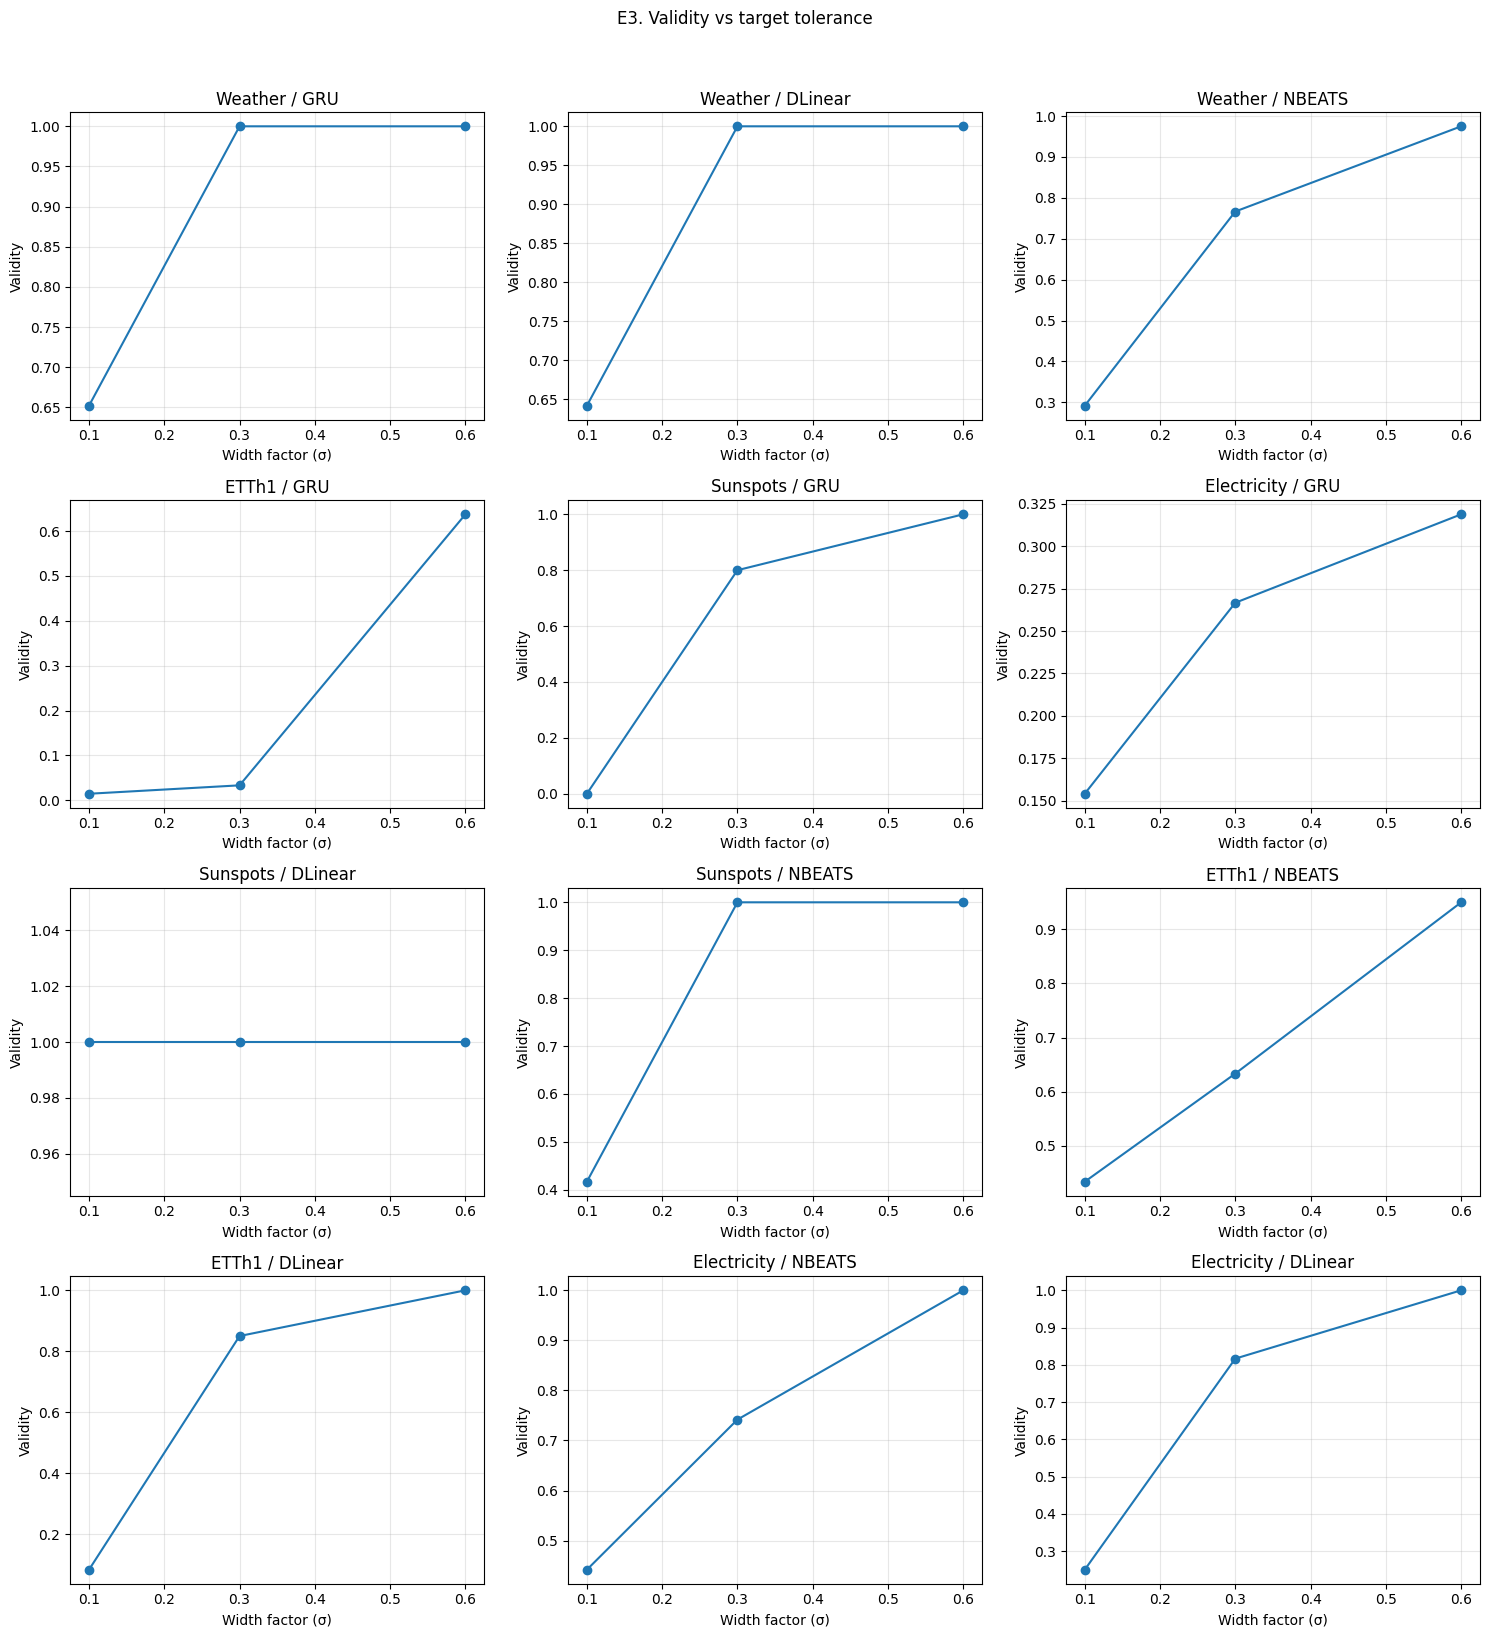

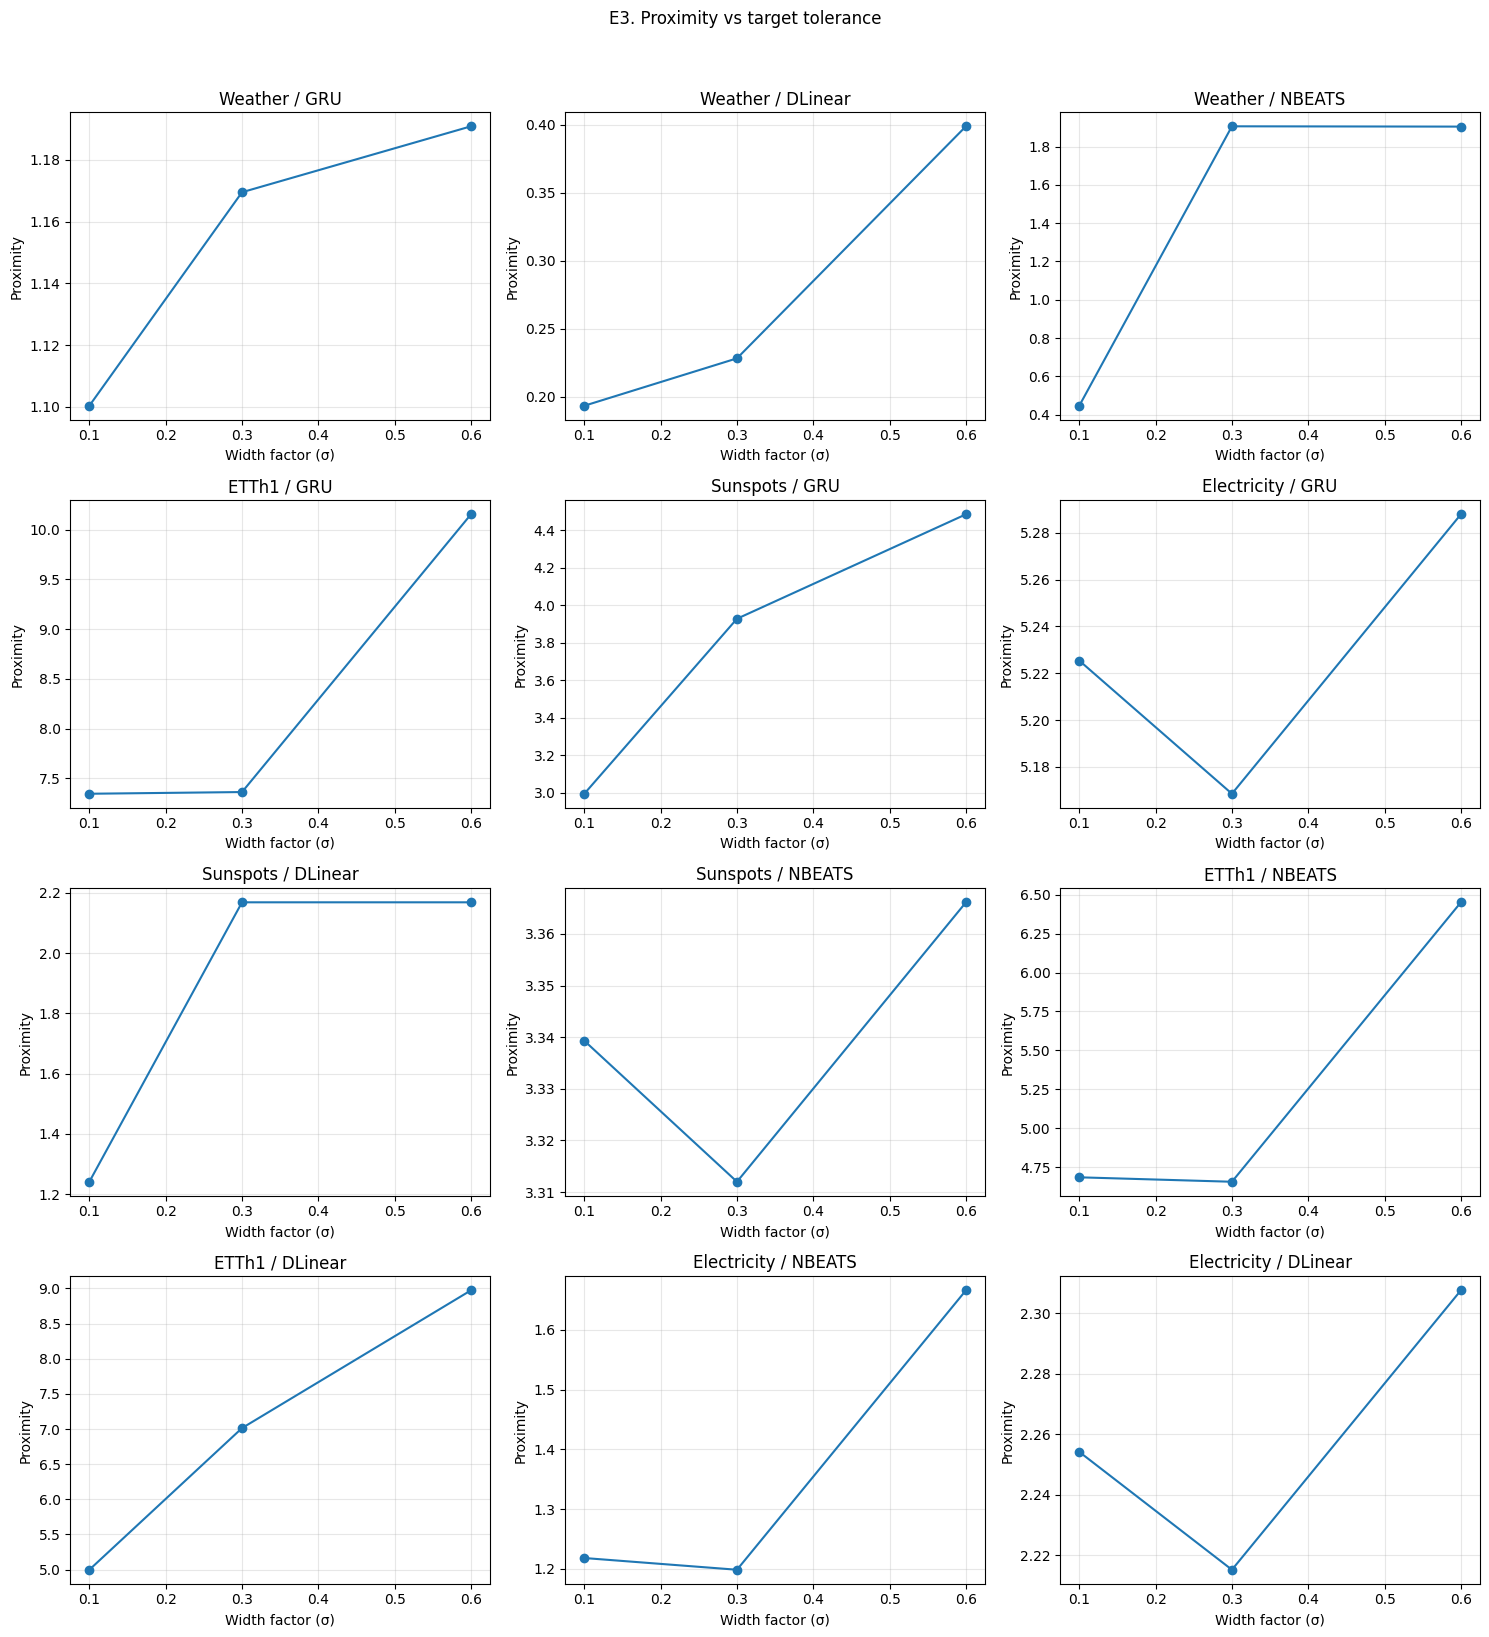

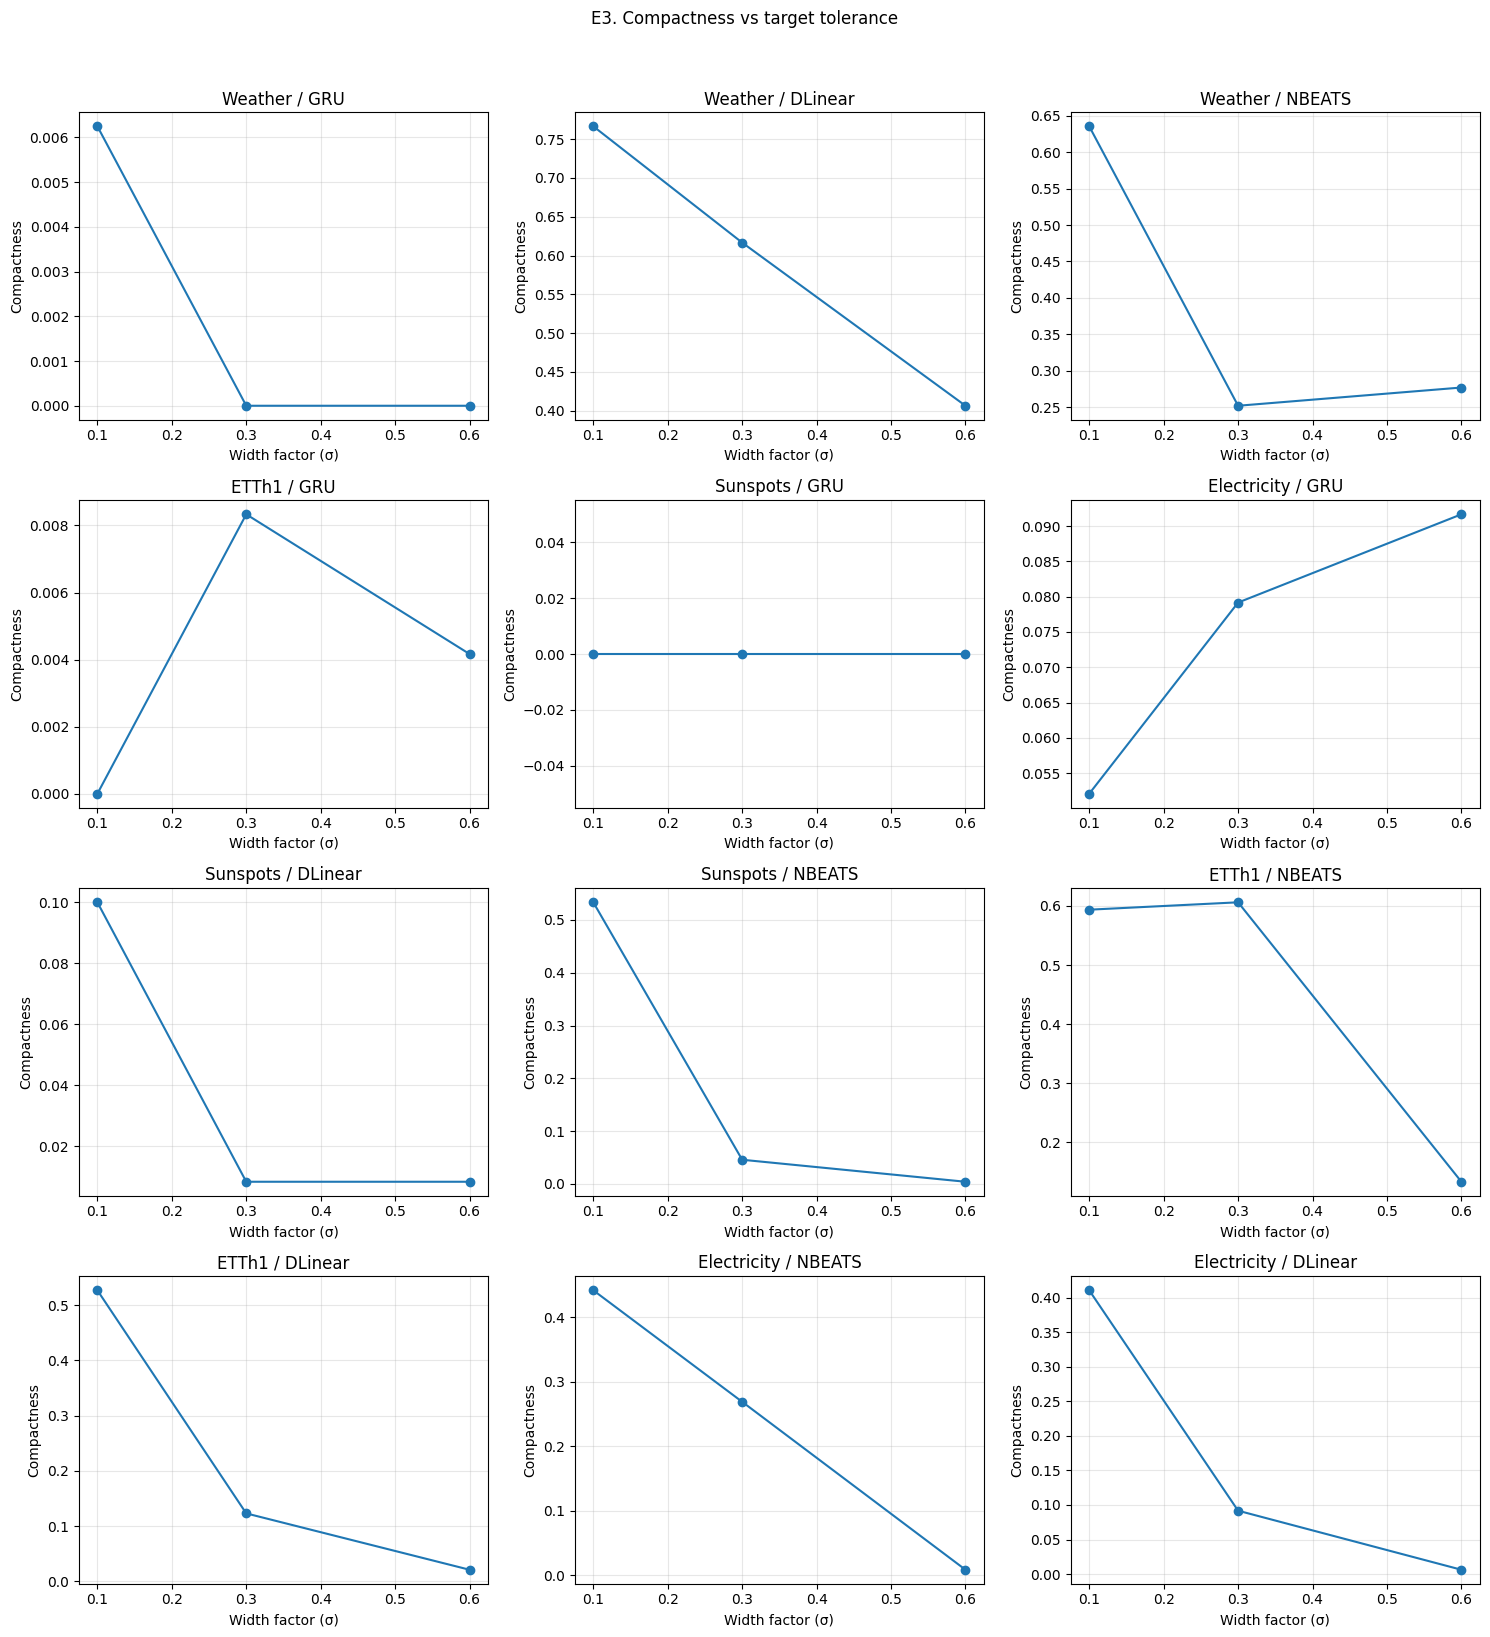

In [73]:
combos_e3 = e3_df[["dataset", "model"]].drop_duplicates().values.tolist()
n_combos  = len(combos_e3)
n_cols    = min(3, n_combos)
n_rows    = int(np.ceil(n_combos / n_cols))

for metric in ["Validity", "Proximity", "Compactness"]:
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False)

    for idx, (ds, m) in enumerate(combos_e3):
        ax  = axes[idx // n_cols][idx % n_cols]
        sub = e3_df[(e3_df["dataset"] == ds) & (e3_df["model"] == m)].sort_values("width")
        ax.plot(sub["width"], sub[metric], marker="o", lw=1.5)
        ax.set_xlabel("Width factor (σ)")
        ax.set_ylabel(metric)
        ax.set_title(f"{ds} / {m}")
        ax.grid(True, alpha=0.3)

    for idx in range(n_combos, n_rows * n_cols):
        axes[idx // n_cols][idx % n_cols].axis("off")

    plt.suptitle(f"E3. {metric} vs target tolerance", y=1.02)
    plt.tight_layout()
    plt.savefig(f"E3_{metric}.png", dpi=100, bbox_inches="tight")
    plt.show()
    plt.close()

## Conclusion E3

Increasing the target band width (from 0.1 * std to 0.6 * std, with a fixed
shift of 0.5 * std) produces consistent effects across all three metrics.

**Validity** increases with width for almost all pairs, which is the expected
result: a wider constraint is easier to satisfy through gradient descent. Some
pairs start from very low values at 0.1 * std (ETTh1/GRU approx. 0.01,
Electricity/GRU approx. 0.15) and never reach 1.0 even at 0.6 * std, indicating
that these architectures require even wider bounds for reliable convergence.
Conversely, Sunspots/DLinear maintains a validity of 1.0 regardless of the width,
suggesting that the constraint is trivially satisfied from 0.1 * std onward for
this pair.

**Proximity** also increases with width in most cases, a less intuitive but
explainable result: a wider band placed beyond the original prediction requires
a larger input modification to reach the center of the target. A few non-monotonic
exceptions appear (Electricity/GRU and Sunspots/NBEATS show a dip at 0.3 * std),
likely due to the variability associated with only 5 instances per configuration.

**Compactness** decreases with width for most pairs: the wider the band, the more
timesteps ForecastCF modifies to reach the target. This is consistent with the
trade-off identified in the original paper, where increasing validity comes at the
cost of reduced compactness.

In practice, a width of 0.3 * std offers the best compromise: it achieves
satisfactory validity (above 0.6 for most pairs) without causing excessive
compactness degradation. This aligns with the empirical recommendations of Wang
et al. (2023), who advise against bounds that are too tight (fr < 0.25) or too
wide (fr > 1).